In [32]:
import math 
class Value:

    def __init__(self, data, _children = (),_op = '', label=""):
        self.data = data 
        self._prev = set(_children)
        self._op = _op 
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad = 1.0 * out.grad 
            other.grad = 1.0 * out.grad
        out._backward = _backward 
        return out 
    
    def __mul__(self, other):
        out = Value(self.data * other.data,(self,other), '*')
        def _backward():
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad
        out._backward = _backward

        return out 

    
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)

        out = Value(t, (self,), 'tanh')   

        def _backward():
            self.grad = (1-t**2)  * out.grad
        out._backward = _backward

        return out 

    

        
# a = Value(20.99, label='a')
# b = Value(-222,  label='b')
# a.__add__(b)
# c = Value(10.0, label='c')
# x = a * b
# x.label = 'x'
# d = x + c
# d.label = 'd'
# e = c * d
# e.label = 'e'
# L = e * f
# L.label = 'L'


In [33]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

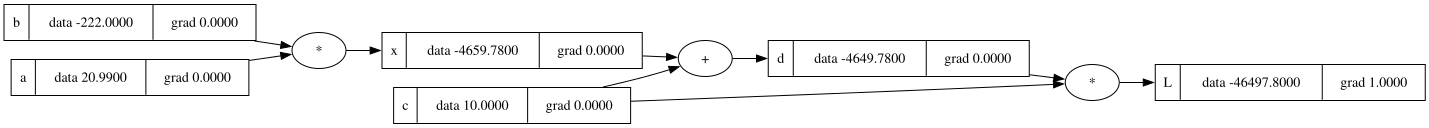

In [34]:
draw_dot(L)

In [35]:
# L.grad = 1.0
# e.grad = -2
# f.grad = -4649.80
# d.grad = -20
# c.grad = 9279.56
# x.grad = -20
# a.grad =-419.8
# b.grad = 4440

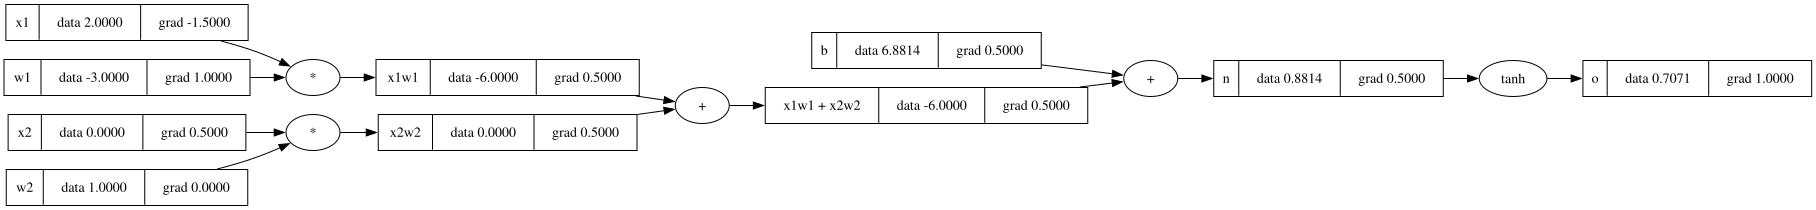

In [41]:
# inputs 
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1
x1w1.label = "x1w1"
x2w2 = x2*w2
x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2 
x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

# o.grad = 1.0
# n.grad = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# x2w2.grad = 0.5
# x1w1.grad = 0.5
# x1.grad = -1.5
# w1.grad = 1
# x2.grad = 0.5
# w2.grad = 0


o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

draw_dot(o)



In [46]:
topo = []
vistited = set()
def build_topo(v):
    if v not in vistited:
        vistited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)


topo

[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]